# zagg write pipeline

Lambda fan-out from the shard maps built in `01_query`: dispatch, futures, cost. Same shardmap, different aggregations; with and without the strict-AOI mask; California at o8 with cost telemetry.

In [1]:
# %pip install "zagg[catalog,viz]"

import io
import json
import logging
import os
import re
import threading
import time
from concurrent.futures import ThreadPoolExecutor
from importlib import resources
from pathlib import Path

import boto3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.parquet as pq
from IPython.display import Markdown

from zagg.catalog import load_polygon
from zagg.catalog.shardmap import ShardMap
from zagg.catalog.sources import Catalog
from zagg.client import Run
from zagg.config import default_config
from zagg.data import demo_aoi
from zagg.grids import from_config
from zagg import notebook as znb
from zagg.notebook import format_max_cost, max_cost_preview

In [2]:
# prefer the 'nasa' profile when it exists (laptop); ambient creds otherwise (hub role)
import botocore.session as _bs

if "nasa" in (_bs.Session().full_config.get("profiles") or {}):
    os.environ.setdefault("AWS_PROFILE", "nasa")
logging.basicConfig(level=logging.INFO, format="%(name)s: %(message)s")
for noisy in ("botocore", "boto3", "urllib3", "s3transfer", "stac_geoparquet"):
    logging.getLogger(noisy).setLevel(logging.WARNING)

OUT = Path("outputs")
STORE = "s3://sliderule-public/zagg-demo"

timings = {}


class stage:
    def __init__(self, name):
        self.name = name

    def __enter__(self):
        self.t0 = time.perf_counter()
        return self

    def __exit__(self, *exc):
        timings[self.name] = round(time.perf_counter() - self.t0, 2)
        print(f"[{self.name}] {timings[self.name]:.1f}s")

## The aggregation template, block by block

In [3]:
raw = (resources.files("zagg.configs") / "atl03_tdigest_healpix_hive.yaml").read_text()


def yaml_block(text, name):
    block = re.search(rf"^{name}:.*?(?=^\w|\Z)", text, re.S | re.M).group(0)
    clean = "\n".join(l for l in block.splitlines() if not l.strip().startswith("#"))
    return Markdown(f"```yaml\n{clean}\n```")

### `data_source` — what to read

- h5coro reads each ATL03 granule directly over S3 by byte range — nothing is downloaded; six beam groups each contribute photon lat/lon/height.
- `index: {backend: inline}` selects the virtual chunk-index for the byte-range reads (vs the pure `hierarchical` metadata walk).
- `filters` drops TEP returns; `levels` + `read_plan` declare the segment→photon index link, so a worker fetches only the segments crossing its shard (`pad: 1`).

In [4]:
yaml_block(raw, "data_source")

```yaml
data_source:
  granule_workers: 4
  reader: h5coro
  driver: s3
  index:
    backend: inline            # virtual chunk-index for the byte-range reads;
  groups: [gt1l, gt1r, gt2l, gt2r, gt3l, gt3r]
  coordinates:
    latitude: "/{group}/heights/lat_ph"
    longitude: "/{group}/heights/lon_ph"
  variables:
    h_ph: "/{group}/heights/h_ph"
  filters:
    - dataset: "/{group}/heights/signal_conf_ph"
      column: 0                  # land surface type; TEP is uniform across columns
      op: ne
      value: -2
  base_level: photons
  levels:
    photons:
      path: "/{group}/heights"
      coordinates: {latitude: lat_ph, longitude: lon_ph}
      link: null
    segments:
      path: "/{group}/geolocation"
      coordinates: {latitude: reference_photon_lat, longitude: reference_photon_lon}
      link:
        to: photons
        index_beg: "/{group}/geolocation/ph_index_beg"
        count: "/{group}/geolocation/segment_ph_cnt"
        index_base: 1            # ATL03 ph_index_beg is 1-based per the v3 dict
  read_plan:
    spatial_index: segments
    pad: 1                       # one segment of padding on each side per #43

```

### `aggregation` — what to compute

- One output field per entry: `count` is a dense per-cell int32; `h_tdigest` is a ragged per-cell t-digest sketch (`delta: 256` centroid budget) from which any quantile is recovered at read time.
- `streaming: {mode: spill}` bounds worker memory: reads spill to `/tmp` partitions and aggregate in one pass after the reads (pooled-identical in the single-block regime; `merge` is the incremental-fold alternative for mergeable reducers).
- Swapping this block changes the science without touching the read or the layout — demoed below with the located variant.

In [5]:
yaml_block(raw, "aggregation")

```yaml
aggregation:
  streaming:
    mode: spill                # bounded read buffers spilled to /tmp partitions, one
  coordinates:
    morton:
      dtype: uint64
      fill_value: 0
  variables:
    count:
      function: len
      source: h_ph
      dtype: int32
      fill_value: 0
    h_tdigest:
      kind: ragged
      function: "zagg.stats.tdigest.build_tdigest"
      source: h_ph
      inner_shape: [2]
      params:
        delta: 256               # centroid budget (accuracy knob)
      dtype: float32
      fill_value: 0

```

### `output` — where it lands

- HEALPix nested grid: `child_order: 19` (~10 m cells); `parent_order: 9` is the dispatch shard (1024×1024 cells, one Lambda invoke each); `chunk_inner: 13` bundles 256 inner chunks into one sharded zarr object.
- `store_layout: hive`: every shard writes its own self-describing leaf zarr; `pyramid: false` keeps the overview sweep off.

In [6]:
yaml_block(raw, "output")

```yaml
output:
  grid:
    type: healpix
    indexing_scheme: nested
    parent_order: 9              # shard / dispatch unit: 4^(19-9) = 1024x1024 cells
    chunk_inner: 13              # inner Zarr chunk: 4^(19-13) = 64x64 cells (K=256 per shard)
    sharded: true                # one ShardingCodec object per array per leaf
    child_order: 19              # leaf cell resolution (~10 m)
  store_layout: hive             # each dispatched shard writes its own leaf zarr
  pyramid: false                 # overview sweep off (untested at demo scale, issue #201)

```

### `worker` — which Lambda runs it

- Selects the pre-provisioned variant: `memory` (2048/4096/8192 MB → `process-shard-<memory>`), `extra_disk: true` picks the `-disk` twin (memory+2048 MB of `/tmp`), which backs the spill partitions.
- The pre-invoke cost ceiling and the metered post-run rollup both key off this block.

In [7]:
yaml_block(raw, "worker")

```yaml
worker:
  memory: 4096                   # pre-provisioned Lambda variant, MB (2048|4096|8192) --
  extra_disk: true               # the -disk twin: memory+2048 MB of /tmp, backing the
```

## SERC — four variants, dispatched in parallel

Each `dispatch()` returns after its setup handshake and `progress_async()` keeps the kernel free, so all four fleets launch back-to-back; one join below blocks once, then the summary compares them.

In [8]:
def clear_store(prefix):
    """Delete every object under an s3://bucket/prefix (paged batch deletes)."""
    bucket, _, key = prefix.removeprefix("s3://").partition("/")
    s3 = boto3.client("s3")
    n = 0
    for page in s3.get_paginator("list_objects_v2").paginate(Bucket=bucket, Prefix=key):
        objs = [{"Key": o["Key"]} for o in page.get("Contents", [])]
        for i in range(0, len(objs), 1000):
            s3.delete_objects(Bucket=bucket, Delete={"Objects": objs[i : i + 1000], "Quiet": True})
        n += len(objs)
    return n


# SERC demo stores are wiped for a clean re-run (the hive template guard refuses
# re-templating over a populated digit tree); California below is KEPT, never wiped.
for name in ("serc_tdigest", "serc_tdigest_aoi", "serc_tdigest_located", "serc_tdigest_strata", "s2_serc_2025"):
    print(f"{name}.zarr: {clear_store(f'{STORE}/{name}.zarr')} objects cleared")

serc_tdigest.zarr: 96 objects cleared
serc_tdigest_aoi.zarr: 104 objects cleared
serc_tdigest_located.zarr: 104 objects cleared
serc_tdigest_strata.zarr: 128 objects cleared
s2_serc_2025.zarr: 1535 objects cleared


In [9]:
serc_map = str(OUT / "shardmap_atl03_serc_o9.json")
config = default_config("atl03_tdigest_healpix_hive")

run = Run.from_config(config, shardmap=serc_map, store=f"{STORE}/serc_tdigest.zarr", overwrite=True)
run

Run(4 shards -> 's3://sliderule-public/zagg-demo/serc_tdigest.zarr', function='process-shard-4096-disk', region='us-west-2')

In [10]:
traces = {}


def track(name, handle):
    """Live bar + per-run completion timeline (latency = first entry, wall = last)."""
    t0 = time.perf_counter()
    times = traces.setdefault(name, [])

    def _drain():
        from tqdm.auto import tqdm

        for _ in tqdm(handle.as_completed(), total=len(handle), desc=name, unit="shard"):
            times.append(time.perf_counter() - t0)

    threading.Thread(target=_drain, daemon=True).start()
    return handle


t0_run = time.perf_counter()
handle = run.dispatch()  # returns after the setup handshake; every shard is a Future
track("combined", handle)  # live bar on a daemon thread -- the kernel is NOT blocked
handle.status()

zagg.runner: Account concurrency: limit=2000, current=0, padding=100, available=1900 -> using 4 workers
zagg.client: Max cost ceiling: ~$0.19 (4 units x 4 GB x 900s, arm64)
earthaccess.auth: You're now authenticated with NASA Earthdata Login
earthaccess.auth: Using token with expiration date 08/27/2026
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


{'pending': 4, 'ok': 0, 'failed': 0}

combined:   0%|          | 0/4 [00:00<?, ?shard/s]

In [11]:
handle.status() | {"cost_so_far_usd": round(handle.cost_usd(), 4)}  # rerun at will while the fleet works

{'pending': 4, 'ok': 0, 'failed': 0, 'cost_so_far_usd': 0.0}

## SERC — same pipeline, with the strict-AOI mask

In [12]:
cat_serc = Catalog.from_geoparquet(str(OUT / "catalog_atl03_serc.parquet"))
serc_parts = load_polygon(demo_aoi("serc"))

masked_config = default_config("atl03_tdigest_healpix_hive")
masked_config.output["aoi_mask"] = True
grid = from_config(masked_config)

sm_masked = ShardMap.build(cat_serc, grid, region=serc_parts, mortie_order=9)
sm_masked.to_json(str(OUT / "shardmap_atl03_serc_o9_aoi.json"))

# in-AOI cell fraction per shard: edge shards are mostly outside the flight box
{
    grid.shard_label(int(k)): round(float(grid.aoi_mask_from_payload(m, grid.children(int(k))).mean()), 3)
    for k, m in zip(sm_masked.shard_keys, sm_masked.aoi_mask)
}

{'4331422411': 0.003,
 '4331422412': 0.566,
 '4331422414': 0.045,
 '4331422421': 0.006}

In [13]:
run_masked = Run.from_config(
    masked_config,
    shardmap=str(OUT / "shardmap_atl03_serc_o9_aoi.json"),
    store=f"{STORE}/serc_tdigest_aoi.zarr",
    overwrite=True,
)
handle_masked = run_masked.dispatch()
track("aoi_mask", handle_masked)
handle_masked.status()

zagg.runner: Account concurrency: limit=2000, current=0, padding=100, available=1900 -> using 4 workers
zagg.client: Max cost ceiling: ~$0.19 (4 units x 4 GB x 900s, arm64)
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


aoi_mask:   0%|          | 0/4 [00:00<?, ?shard/s]

{'pending': 4, 'ok': 0, 'failed': 0}

In [14]:
handle_masked.status() | {"cost_so_far_usd": round(handle_masked.cost_usd(), 4)}  # rerun at will while the fleet works

{'pending': 4, 'ok': 0, 'failed': 0, 'cost_so_far_usd': 0.0}

The mask drops no photons — the masked store additionally carries a per-cell `aoi_mask` bool array, which readers use to clip whole-shard overhang at the AOI edge.

## SERC — same shardmap, different aggregation: located t-digest

Same `build_tdigest` reducer — the single delta is `location: leaf_id`, which adds a per-centroid morton location channel (order-29 photon words folded via `common_ancestor`, stored as the row-aligned `h_tdigest_locations` companion array).

In [15]:
located_config = default_config("atl03_tdigest_healpix_hive")
# graft the located VARIABLES only -- coordinates and the streaming block stay the template's
located_config.aggregation["variables"] = default_config("atl03_tdigest_located_healpix").aggregation["variables"]

located_yaml = (resources.files("zagg.configs") / "atl03_tdigest_located_healpix.yaml").read_text()
yaml_block(located_yaml, "aggregation")

```yaml
aggregation:
  coordinates:
    morton:
      dtype: uint64
      fill_value: 0
  variables:
    count:
      function: len
      source: h_ph
      dtype: int32
      fill_value: 0
    h_tdigest:
      kind: ragged
      function: "zagg.stats.tdigest.build_tdigest"
      source: h_ph
      location: leaf_id
      inner_shape: [2]
      params:
        delta: 256
      dtype: float32
      fill_value: 0

```

In [16]:
run_located = Run.from_config(
    located_config, shardmap=serc_map, store=f"{STORE}/serc_tdigest_located.zarr", overwrite=True
)
handle_located = run_located.dispatch()
track("located", handle_located)
handle_located.status()

zagg.runner: Account concurrency: limit=2000, current=0, padding=100, available=1900 -> using 4 workers
zagg.client: Max cost ceiling: ~$0.19 (4 units x 4 GB x 900s, arm64)
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


located:   0%|          | 0/4 [00:00<?, ?shard/s]

{'pending': 4, 'ok': 0, 'failed': 0}

## SERC — signal/noise strata (the split t-digest)

The production-direction template: TWO digests per cell — `h_tdigest_signal` / `h_tdigest_noise`, split by the per-surface confidence union (`>= 2` on any of the five `signal_conf_ph` columns, declared as column-selected variables in `data_source`) — plus a packed per-cell `composition` lanes field. Both strata also carry `location: leaf_id`, so strata and location compose.

In [17]:
strata_config = default_config("atl03_tdigest_strata_healpix")
strata_config.output = default_config("atl03_tdigest_healpix_hive").output  # same hive grid/layout
strata_config.worker = dict(default_config("atl03_tdigest_healpix_hive").worker)  # 4096-disk
strata_config.aggregation["streaming"] = {"mode": "spill"}  # same spill path as the template

strata_yaml = (resources.files("zagg.configs") / "atl03_tdigest_strata_healpix.yaml").read_text()
yaml_block(strata_yaml, "aggregation")

```yaml
aggregation:
  coordinates:
    morton:
      dtype: uint64
      fill_value: 0
  variables:
    count:
      function: len
      source: h_ph
      dtype: int32
      fill_value: 0
    h_tdigest_signal:
      kind: ragged
      function: "zagg.stats.tdigest.build_tdigest_where"
      source: h_ph
      location: leaf_id
      inner_shape: [2]
      params:
        delta: 256
        where: >-
          (signal_conf_land >= 2) | (signal_conf_ocean >= 2) |
          (signal_conf_sea_ice >= 2) | (signal_conf_land_ice >= 2) |
          (signal_conf_inland_water >= 2)
      dtype: float32
      fill_value: 0
      attrs:
        stratum: signal
        signal_threshold: 2
    h_tdigest_noise:
      kind: ragged
      function: "zagg.stats.tdigest.build_tdigest_where"
      source: h_ph
      location: leaf_id
      inner_shape: [2]
      params:
        delta: 256
        where: >-
          ~((signal_conf_land >= 2) | (signal_conf_ocean >= 2) |
          (signal_conf_sea_ice >= 2) | (signal_conf_land_ice >= 2) |
          (signal_conf_inland_water >= 2))
      dtype: float32
      fill_value: 0
      attrs:
        stratum: noise
        signal_threshold: 2
    composition:
      function: "zagg.stats.composition.pack_composition"
      source: h_ph
      dtype: uint64
      fill_value: 0
      params:
        conf_land: signal_conf_land
        conf_ocean: signal_conf_ocean
        conf_sea_ice: signal_conf_sea_ice
        conf_land_ice: signal_conf_land_ice
        conf_inland_water: signal_conf_inland_water
        threshold: 2
      attrs:
        composition:
          spec: zagg-composition/1
          lanes: [land, ocean, sea_ice, land_ice, inland_water, low, med, high]
          of: h_tdigest_signal        # N_signal = this digest's total weight
          threshold: 2

```

In [18]:
run_strata = Run.from_config(
    strata_config, shardmap=serc_map, store=f"{STORE}/serc_tdigest_strata.zarr", overwrite=True
)
handle_strata = run_strata.dispatch()
track("strata", handle_strata)
handle_strata.status()

zagg.runner: Account concurrency: limit=2000, current=0, padding=100, available=1900 -> using 4 workers
zagg.client: Max cost ceiling: ~$0.19 (4 units x 4 GB x 900s, arm64)
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


{'pending': 4, 'ok': 0, 'failed': 0}

strata:   0%|          | 0/4 [00:00<?, ?shard/s]

## Stop executing

All four fleets are in flight — join once, then compare:

In [22]:
for h in (handle, handle_masked, handle_located, handle_strata):
    h.wait()
timings["SERC: 4 variants (parallel)"] = round(time.perf_counter() - t0_run, 2)
print(f"all four runs complete in {timings['SERC: 4 variants (parallel)']:.1f}s wall (parallel)")
{
    name: h.status()
    for name, h in [
        ("combined", handle),
        ("aoi_mask", handle_masked),
        ("located", handle_located),
        ("strata", handle_strata),
    ]
}

all four runs complete in 182.7s wall (parallel)


{'combined': {'pending': 0, 'ok': 4, 'failed': 0},
 'aoi_mask': {'pending': 0, 'ok': 4, 'failed': 0},
 'located': {'pending': 0, 'ok': 4, 'failed': 0},
 'strata': {'pending': 0, 'ok': 4, 'failed': 0}}

In [23]:
res = next(iter(handle.futures.values())).result()
print(f"metered cost: ${handle.cost_usd():.4f} (billed-duration rollup, same figure the CLI prints)")
{k: res.get(k) for k in ("shard_key", "wall_time", "lambda_duration", "retries")} | {
    k: v for k, v in res["body"].items() if isinstance(v, (int, float, str))
}

metered cost: $0.0190 (billed-duration rollup, same figure the CLI prints)


{'shard_key': 5347395636851376137,
 'wall_time': 103.90383386611938,
 'lambda_duration': 99.756674,
 'retries': 0,
 'cells_with_data': 104941,
 'total_obs': 3741239,
 'granule_count': 68,
 'files_processed': 68,
 'duration_s': 99.756674,
 'container_hwm_mb': 614.8515625,
 'max_memory_mb': 610.9375,
 'cpu_seconds': 119.41,
 'container_cold': False,
 'container_generation': 4,
 'rss_start_mb': 360.6484375,
 'sandbox_id': '2026/08/04/[$LATEST]800442daa26142a4813114d66869c759',
 'container_init_ts': 1785818976.8785625}

Cost across the four SERC variants — same shardmap, same photons, different aggregation blocks:

In [24]:
def rollup(h, name):
    bodies = [f.result().get("body", {}) for f in h.futures.values()]
    tl = traces.get(name, [])
    return {
        "cost_usd": round(h.cost_usd(), 4),
        "cells_with_data (M)": round(sum(b.get("cells_with_data") or 0 for b in bodies) / 1e6, 3),
        "total_obs (M)": round(sum(b.get("total_obs") or 0 for b in bodies) / 1e6, 2),
        "latency (min)": round(tl[0] / 60, 2) if tl else None,
        "wall (min)": round(tl[-1] / 60, 2) if tl else None,
    }


pd.DataFrame(
    {
        "combined": rollup(handle, "combined"),
        "combined + aoi_mask": rollup(handle_masked, "aoi_mask"),
        "located": rollup(handle_located, "located"),
        "signal/noise strata (located)": rollup(handle_strata, "strata"),
    }
).T

,cost_usd,cells_with_data (M),total_obs (M),latency (min),wall (min)
combined,0.0190,0.417,20.94,1.18,1.73
combined + aoi_mask,0.0197,0.417,20.94,1.43,2.02
located,0.0180,0.417,20.94,1.03,1.84
signal/noise strata (located),0.0225,0.417,20.94,1.54,2.27


## SERC — Sentinel-2 raster write (the raster module)

- Same grid family: each datatake's COGs are sampled at the o19 cell centres into `(time, cells)` arrays — the S2 store shares the cells axis with the photon stores, so co-registration is index arithmetic.
- `zagg.client` v1 is point-path-only; raster dispatch rides `zagg.notebook.run` (the `agg` wrapper: ceiling print, progress bar, `RunView` cost report).
- One year (2025) to bound the demo — drop the year filter to ingest the full archive.

| axis | points (ATL03) | raster (S2) |
|---|---|---|
| store | hive + **sharded** (1 object/array/leaf) | hive + **unsharded** `(1, cells)` slabs |
| aggregation | explicit block (digests, strata) | none — the reader *is* the aggregation (pull-NN) |
| memory | spill to `/tmp` (`-disk` worker) | bounded per datatake; no spill, base worker |
| fan-out unit | shard | shard × full time axis (windowing off) |

Every difference is load-bearing: sharding is off because workers write per-timestep slabs; spill is absent because nothing pools.

In [36]:
s2_yaml = (resources.files("zagg.configs") / "sentinel2_l2a.yaml").read_text()
# raster templates have no aggregation block: the reader IS the aggregation
# (each band pull-sampled at the o19 cell centres into (time, cells) arrays)
Markdown("\n".join(yaml_block(s2_yaml, block).data for block in ("data_source", "output")))

```yaml
data_source:
  reader: raster
  bands:
    red: {asset: red, dtype: uint16, fill_value: 0, scale: 0.0001, offset: -0.1}
    green: {asset: green, dtype: uint16, fill_value: 0, scale: 0.0001, offset: -0.1}
    blue: {asset: blue, dtype: uint16, fill_value: 0, scale: 0.0001, offset: -0.1}
    nir: {asset: nir, dtype: uint16, fill_value: 0, scale: 0.0001, offset: -0.1}
    scl: {asset: scl, dtype: uint8, fill_value: 0}
  nodata: 0
  anonymous: true

```
```yaml
output:
  grid:
    type: healpix
    parent_order: 11
    child_order: 19
  store: ./sentinel2_l2a.zarr
```

In [37]:
s2_full = Catalog.from_geoparquet(str(OUT / "catalog_s2_serc.parquet"))
s2_2025 = Catalog(
    s2_full.table.filter(pc.equal(pc.year(s2_full.table.column("datetime")), 2025)),
    dict(s2_full.metadata),
)

s2_config = default_config("sentinel2_l2a")
s2_config.output["grid"]["parent_order"] = 9

sm_s2_2025 = ShardMap.build(s2_2025, from_config(s2_config), region=serc_parts, mortie_order=9)
sm_s2_2025.to_json(str(OUT / "shardmap_s2_serc_2025_o9.json"))
print(
    f"{len(s2_2025):,} items in 2025 -> {sm_s2_2025.metadata['total_shards']} shards, "
    f"{sm_s2_2025.metadata['total_pairs']:,} (shard, datatake) pairs"
)

85 items in 2025 -> 4 shards, 340 (shard, datatake) pairs


In [39]:
_t0_s2 = time.perf_counter()
s2_future = ThreadPoolExecutor(1).submit(
    znb.run,
    s2_config,
    catalog=str(OUT / "shardmap_s2_serc_2025_o9.json"),
    backend="lambda",
    store=f"{STORE}/s2_serc_2025.zarr",
    overwrite=True,
    profile=True,  # per-stage fetch/decode/sample/write splits in the stats parquet
)
# the runner's own tqdm bar renders above; the kernel stays free -- join below

Max cost ceiling: ~$0.19 (4 units x 4 GB x 900s, arm64)


shards:   0%|          | 0/4 [00:00<?, ?unit/s]

zagg.runner: Max cost ceiling: ~$0.19 (4 units x 4 GB x 900s, arm64)
zagg.runner: Async raster results at s3://sliderule-public/zagg-demo/s2_serc_2025.zarr.status/8132ee96b12740cb86482ad591b838bd
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


In [ ]:
s2_view = s2_future.result()  # join: blocks until the raster run (and its tail) lands
timings["SERC: S2 raster run (2025)"] = round(time.perf_counter() - _t0_s2, 2)
s2_view

zagg.runner: Max cost ceiling: ~$0.19 (4 units x 4 GB x 900s, arm64)
zagg.runner: Async raster results at s3://sliderule-public/zagg-demo/s2_serc_2025.zarr.status/82b845ceee5e44dbabd06372ca78c1ac
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


## California at o9 — full state, standard tier

The production shape end to end: **strata (signal/noise, located)** aggregation, hive + sharded o9 shards, `process-shard-4096-disk` with spill, sidecar chunk-index in write-through mode, pyramid off. No fat tail at this order (the o8 campaign that proved that lives in `04_california_o8.ipynb`). Dispatched on the **event transport** — at 2,721 shards the status-object channel is what lands the run parquet (the sync transport's inline budget caps out ~500 rows), holds no connections, and makes the run reattachable by id. The store is kept, never wiped.

In [19]:
ca_config = default_config("atl03_tdigest_strata_healpix")
ca_config.output = default_config("atl03_tdigest_healpix_hive").output  # hive + sharded, parent_order 9, pyramid off
ca_config.worker = {"memory": 4096, "extra_disk": True}
ca_config.aggregation["streaming"] = {"mode": "spill"}
# write-through sidecar chunk-index: warm for the whole state from the o8 campaign
ca_config.data_source["index"] = {
    "backend": "sidecar",
    "on_miss": "build",
    "store": "s3://sliderule-public-cors/zagg-index/ATL03/007",
}
ca_map = str(OUT / "shardmap_california_o9.json")

print(format_max_cost(max_cost_preview(ca_config, catalog=ca_map)))

Max cost ceiling: ~$130.61 (2721 units x 4 GB x 900s, arm64)


In [20]:
CA_STORE = f"{STORE}/california_tdigest_o9.zarr"  # KEPT across sessions, never wiped

run_ca = Run.from_config(ca_config, shardmap=ca_map, store=CA_STORE, overwrite=True)

t0 = time.perf_counter()
# max_workers: explicit pacing window (the probe clamps to the kernel's fd
# ceiling -- vestigial for the event transport, which holds no sockets); 1800
# sits under the ~1900 account headroom and pulls small shards into wave one
handle_ca = run_ca.dispatch(transport="event", max_workers=1800)
completions = []


def _trace():
    from tqdm.auto import tqdm

    for _ in tqdm(handle_ca.as_completed(), total=len(handle_ca), desc="shards", unit="shard"):
        completions.append(time.perf_counter() - t0)


threading.Thread(target=_trace, name="ca-trace", daemon=True).start()
handle_ca.status()

zagg.runner: Account concurrency: limit=2000, current=17, padding=100, available=1883 -> using 1883 workers
zagg.client: Max cost ceiling: ~$130.61 (2721 units x 4 GB x 900s, arm64)
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


{'pending': 2721, 'ok': 0, 'failed': 0}

shards:   0%|          | 0/2721 [00:00<?, ?shard/s]

In [28]:
handle_ca.status() | {"cost_so_far_usd": round(handle_ca.cost_usd(), 4)}  # rerun at will while the fleet works

{'pending': 1787, 'ok': 934, 'failed': 0, 'cost_so_far_usd': 7.0528}

In [29]:
handle_ca.wait()  # join: every shard AND the post-run tail (finalize, coverage, stats, sweep)
timings["California: o9 run"] = round(time.perf_counter() - t0, 2)
print(
    f"first shard done at {completions[0]:.1f}s; "
    f"full state at {completions[-1]:.1f}s ({len(completions)} shards)"
)

zagg.runner: Dispatched run stats write (2721 rows, fire-and-forget): s3://sliderule-public/zagg-demo/california_tdigest_o9.zarr/stats_20260804T051621Z_0c56df7ce58644c38bed26415e7deb7e.parquet


first shard done at 321.6s; full state at 891.8s (2721 shards)


Per-shard telemetry lands as a parquet at the store root — the event transport's pointer path carries all 2,721 rows.

In [30]:
from zagg import runner as _runner
from zagg.client import ShardError
from zagg.dispatch import LAMBDA_PRICE_PER_GB_SEC


def _handle_results(handle):
    out = []
    for key, fut in handle.futures.items():
        exc = fut.exception()
        if exc is None:
            out.append(fut.result())
        elif isinstance(exc, ShardError):
            out.append(exc.payload)
        else:
            out.append({"shard_key": key, "status_code": None, "body": {},
                        "error": f"{type(exc).__name__}: {exc}", "retries": None})
    return out


def fetch_run_stats(store_path, handle=None):
    """The store parquet when present, else rows rebuilt from the handle."""
    bucket, _, prefix = store_path.removeprefix("s3://").partition("/")
    s3 = boto3.client("s3")
    objs = s3.list_objects_v2(Bucket=bucket, Prefix=f"{prefix}/stats_").get("Contents", [])
    if objs:
        key = max(o["Key"] for o in objs)  # timestamp-first names sort chronologically
        return pq.read_table(io.BytesIO(s3.get_object(Bucket=bucket, Key=key)["Body"].read())).to_pandas()
    assert handle is not None, "no stats parquet and no handle to rebuild from"
    rows, _ = _runner._lambda_result_rows(_handle_results(handle), run_id="notebook-rebuild")
    return pd.DataFrame(rows)


stats = fetch_run_stats(handle_ca.store_path, handle=handle_ca)
ok = stats[stats.success.fillna(False)]
fails = stats[~stats.success.fillna(False)]
memory_gb = _runner._worker_memory_gb(ca_config)
billed = stats.est_cost_usd.fillna(stats.duration_s * memory_gb * LAMBDA_PRICE_PER_GB_SEC).sum()
print(
    f"worker-reported cost ${stats.est_cost_usd.sum():.2f}; billed estimate incl. "
    f"{len(fails)} failed attempts ${billed:.2f} | "
    f"{stats.duration_s.sum():,.0f} lambda-seconds, {ok.n_obs.sum() / 1e9:.2f}B photons"
)
if len(fails):
    print("failure classes:")
    print(fails.error_class.str[:60].value_counts().to_string())
stats[["duration_s", "n_obs", "n_granules", "max_memory_mb", "est_cost_usd"]].describe().round(4)

worker-reported cost $21.54; billed estimate incl. 0 failed attempts $21.54 | 403,888 lambda-seconds, 37.15B photons


,duration_s,n_obs,n_granules,max_memory_mb,est_cost_usd
count,2721.0000,2.721000e+03,2721.0000,2721.0000,2721.0000
mean,148.4336,1.365206e+07,70.0570,1089.7755,0.0079
std,33.6373,7.461750e+06,8.1527,406.2562,0.0018
min,77.0760,2.728726e+06,54.0000,438.6016,0.0041
25%,126.7571,9.075554e+06,64.0000,824.7031,0.0068
50%,144.8831,1.203212e+07,67.0000,1014.8594,0.0077
75%,163.1371,1.595650e+07,76.0000,1245.5469,0.0087
max,365.0188,7.216157e+07,102.0000,3974.6719,0.0195


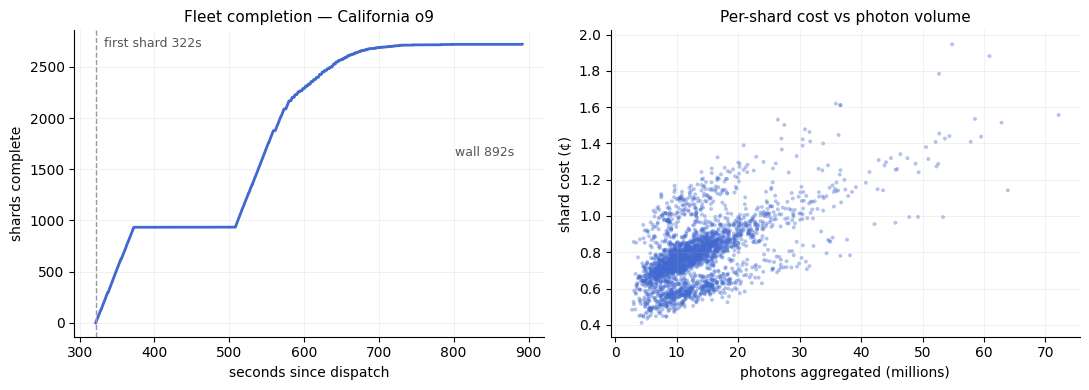

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

t = np.asarray(completions)
ax1.step(t, np.arange(1, len(t) + 1), where="post", color="#4269d0", lw=2)
ax1.axvline(t[0], color="#9498a0", lw=1, ls="--")
ax1.annotate(f"first shard {t[0]:.0f}s", (t[0], len(t)), xytext=(6, -2), textcoords="offset points", fontsize=9, color="#555")
ax1.annotate(f"wall {t[-1]:.0f}s", (t[-1], len(t) * 0.6), xytext=(-6, 0), textcoords="offset points", ha="right", fontsize=9, color="#555")
ax1.set_xlabel("seconds since dispatch")
ax1.set_ylabel("shards complete")
ax1.set_title("Fleet completion — California o9", fontsize=11)

ax2.scatter(stats.n_obs / 1e6, stats.est_cost_usd * 100, s=8, alpha=0.4, color="#4269d0", edgecolors="none")
ax2.set_xlabel("photons aggregated (millions)")
ax2.set_ylabel("shard cost (¢)")
ax2.set_title("Per-shard cost vs photon volume", fontsize=11)

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.25, lw=0.5)
plt.tight_layout()

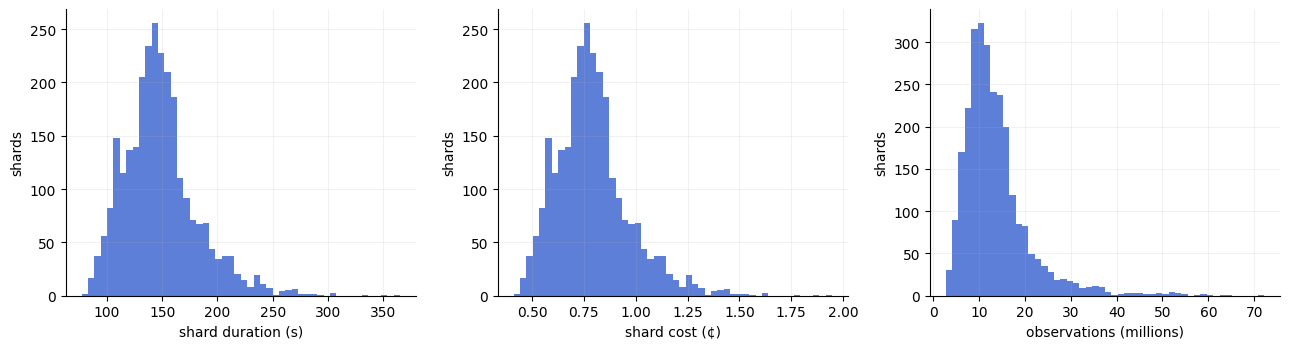

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
panels = [("duration_s", "shard duration (s)", 1.0),
          ("est_cost_usd", "shard cost (\u00a2)", 100.0),
          ("n_obs", "observations (millions)", 1e-6)]
for ax, (col, label, scale) in zip(axes, panels):
    ax.hist(stats[col].dropna() * scale, bins=50, color="#4269d0", alpha=0.85)
    ax.set_xlabel(label)
    ax.set_ylabel("shards")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.25, lw=0.5)
plt.tight_layout()

In [33]:
folded = stats.get("spill_blocks_closed")
run_summary = {
    "shards": len(stats),
    "succeeded": int(stats.success.sum()),
    "total_obs (B)": round(float(ok.n_obs.sum()) / 1e9, 2),
    "cells_with_data (M)": round(float(ok.cells_with_data.sum()) / 1e6, 2) if "cells_with_data" in ok else "n/a",
    "granule reads": f"{int(stats.n_granules.sum()):,}",
    "lambda-hours": round(float(stats.duration_s.sum()) / 3600, 1),
    "spill volume (GB, to /tmp)": round(float(stats.spill_bytes.fillna(0).sum()) / 2**30, 1) if "spill_bytes" in stats else "n/a",
    "actual cost (USD)": round(float(billed), 2),
    "shard duration min (median / p95 / max)": f"{stats.duration_s.median() / 60:.1f} / {stats.duration_s.quantile(0.95) / 60:.1f} / {stats.duration_s.max() / 60:.1f}",
    "max_memory_mb (median / max)": f"{stats.max_memory_mb.median():,.0f} / {stats.max_memory_mb.max():,.0f}",
    "spill fold regime (shards)": int((folded.fillna(0) > 0).sum()) if folded is not None else "n/a",
    "latency min (first shard)": round(completions[0] / 60, 2),
    "wall min (full state)": round(completions[-1] / 60, 2),
}
pd.Series(run_summary, name="California o9").to_frame()

,California o9
shards,2721
succeeded,2721
total_obs (M),37147.3
cells_with_data (M),462.33
granule reads,"190,625"
lambda-seconds,"403,888"
actual cost (USD),21.54
shard duration min (median / p95 / max),2.4 / 3.5 / 6.1
max_memory_mb (median / max),"1,015 / 3,975"
spill fold regime (shards),0


In [34]:
# same columns as the SERC variant table, for cross-section comparison
pd.DataFrame(
    {
        "california o9 (strata, located)": {
            "cost_usd": round(float(billed), 4),
            "cells_with_data (M)": round(float(ok.cells_with_data.sum()) / 1e6, 3) if "cells_with_data" in ok else None,
            "total_obs (B)": round(float(ok.n_obs.sum()) / 1e9, 2),
            "latency (min)": round(completions[0] / 60, 2),
            "wall (min)": round(completions[-1] / 60, 2),
        }
    }
).T

,cost_usd,cells_with_data (M),total_obs (M),latency (min),wall (min)
"california o9 (strata, located)",21.5408,462.328,37147.26,5.36,14.86


## Timings

In [35]:
(OUT / "timings_write.json").write_text(json.dumps(timings, indent=2))
pd.Series(timings, name="seconds").to_frame()

,seconds
SERC: 4 variants (parallel),182.68
California: o9 run,898.33
